In [1]:
!pip install tensorflow

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import random
import string
import pandas as pd

# -------------------------
# Helper Functions
# -------------------------

def random_string(length=6):
    return ''.join(random.choices(string.ascii_lowercase + string.digits, k=length))

def generate_safe_url():
    legit_domains = [
        "google.com", "github.com", "amazon.in", "microsoft.com",
        "wikipedia.org", "apple.com", "linkedin.com",
        "iitb.ac.in", "stackoverflow.com"
    ]

    domain = random.choice(legit_domains)
    protocol = random.choice(["https://", "http://"])

    paths = ["", "/about", "/home", "/products", "/contact", "/services"]
    query = ["", "?id=123", "?page=2", "?ref=homepage"]

    return protocol + domain + random.choice(paths) + random.choice(query)

def generate_phishing_url():
    keywords = ["login", "verify", "secure", "update", "account", "bank"]
    brands = ["paypal", "amazon", "google", "facebook", "bankofindia"]
    tlds = [".ru", ".tk", ".ml", ".ga", ".cf", ".xyz"]

    pattern_type = random.randint(1,4)

    if pattern_type == 1:
        # keyword-brand.ru
        domain = random.choice(keywords) + "-" + random.choice(brands) + random.choice(tlds)
        return "http://" + domain + "/" + random.choice(keywords)

    elif pattern_type == 2:
        # brand-secure123.com
        domain = random.choice(brands) + "-secure" + random_string(3) + ".com"
        return "https://" + domain + "/verify-account"

    elif pattern_type == 3:
        # IP based phishing
        ip = ".".join(str(random.randint(10,255)) for _ in range(4))
        return "http://" + ip + "/login.php?id=" + random_string(5)

    else:
        # subdomain trick
        domain = random.choice(brands) + ".security-" + random.choice(keywords) + random.choice(tlds)
        return "http://" + domain + "/update"

# -------------------------
# Generate Dataset
# -------------------------

data = []

# Safe URLs
for _ in range(1000):
    data.append([generate_safe_url(), 0])

# Phishing URLs
for _ in range(1000):
    data.append([generate_phishing_url(), 1])

# Create DataFrame
df = pd.DataFrame(data, columns=["url", "label"])

# Shuffle dataset
df = df.sample(frac=1).reset_index(drop=True)

# Save file
df.to_csv("dataset.csv", index=False)

print("Realistic dataset created successfully!")
print("Total samples:", len(df))
df.head()

Realistic dataset created successfully!
Total samples: 2000


,url,label
0,http://iitb.ac.in/services?page=2,0
1,https://amazon.in/home?ref=homepage,0
2,http://paypal.security-verify.cf/update,1
3,https://bankofindia-secure3xc.com/verify-account,1
4,http://stackoverflow.com?ref=homepage,0


In [4]:
df['label'].value_counts()
df.shape

(2000, 2)

In [5]:
df['label'].value_counts()

,count
label,
0,1000
1,1000


In [6]:
df.isnull().sum()

,0
url,0
label,0


In [7]:
from sklearn.model_selection import train_test_split

X_text = df['url']
y = df['label']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

Training samples: 1600
Testing samples: 400


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3,5),
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

X_train_tfidf.shape

(1600, 5000)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC()
}

for name, model in models.items():
    print("\n==============================")
    print(name)

    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Logistic Regression
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       200
           1       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400


Random Forest
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       200
           1       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400


Decision Tree
Accuracy: 0.99
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       200
           1       1.00      0.98      0.99       200

    accuracy                           0.99       400
   macro avg       0.99      0.99 

In [10]:
best_model = RandomForestClassifier()
best_model.fit(X_train_tfidf, y_train)

RandomForestClassifier()

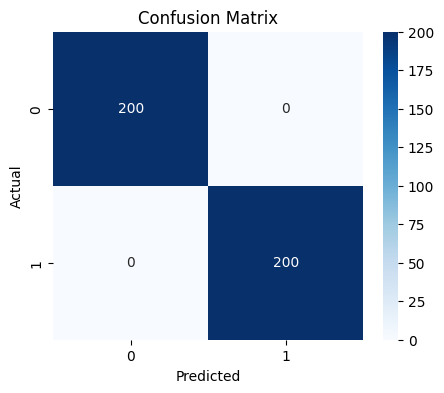

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = best_model.predict(X_test_tfidf)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [12]:
def predict_url(url):
    transformed = vectorizer.transform([url])
    prediction = best_model.predict(transformed)[0]
    prob = best_model.predict_proba(transformed)[0][prediction]

    if prediction == 1:
        print(f"⚠️ Phishing URL (Confidence: {prob:.2f})")
    else:
        print(f"✅ Safe URL (Confidence: {prob:.2f})")

In [13]:
predict_url("http://secure-paypal-login.ru")
predict_url("https://google.com")

⚠️ Phishing URL (Confidence: 0.77)
✅ Safe URL (Confidence: 1.00)


In [14]:
import re
import socket
from urllib.parse import urlparse
import numpy as np

def has_ip(url):
    try:
        socket.inet_aton(urlparse(url).netloc)
        return 1
    except:
        return 0

def manual_features(url):
    features = []

    # Length of URL
    features.append(len(url))

    # Number of dots
    features.append(url.count('.'))

    # Number of hyphens
    features.append(url.count('-'))

    # Presence of @
    features.append(1 if '@' in url else 0)

    # Uses HTTPS
    features.append(1 if url.startswith("https") else 0)

    # Suspicious words
    suspicious = ["login", "verify", "secure", "update", "account", "bank"]
    features.append(1 if any(word in url.lower() for word in suspicious) else 0)

    # IP Address
    features.append(has_ip(url))

    return features

In [15]:
# Generate manual features
X_train_manual = np.array([manual_features(url) for url in X_train_text])
X_test_manual = np.array([manual_features(url) for url in X_test_text])

X_train_manual.shape

(1600, 7)

In [16]:
from scipy.sparse import hstack

X_train_hybrid = hstack([X_train_tfidf, X_train_manual])
X_test_hybrid = hstack([X_test_tfidf, X_test_manual])

X_train_hybrid.shape

(1600, 5007)

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

hybrid_model = RandomForestClassifier()
hybrid_model.fit(X_train_hybrid, y_train)

y_pred_hybrid = hybrid_model.predict(X_test_hybrid)

print("Hybrid Model Accuracy:", accuracy_score(y_test, y_pred_hybrid))
print(classification_report(y_test, y_pred_hybrid))

Hybrid Model Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       200
           1       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [18]:
def predict_url_hybrid(url):
    tfidf = vectorizer.transform([url])
    manual = np.array(manual_features(url)).reshape(1, -1)

    combined = hstack([tfidf, manual])

    prediction = hybrid_model.predict(combined)[0]
    prob = hybrid_model.predict_proba(combined)[0][prediction]

    if prediction == 1:
        print(f"⚠️ Phishing URL (Confidence: {prob:.2f})")
    else:
        print(f"✅ Safe URL (Confidence: {prob:.2f})")

In [19]:
predict_url_hybrid("http://secure-login-paypal.ru")
predict_url_hybrid("https://google.com")

⚠️ Phishing URL (Confidence: 0.95)
✅ Safe URL (Confidence: 1.00)


In [20]:
!pip install shap

In [21]:
import shap

In [24]:
# Convert everything to float32 safely
X_train_tfidf = X_train_tfidf.astype(np.float32)
X_test_tfidf = X_test_tfidf.astype(np.float32)

X_train_manual = X_train_manual.astype(np.float32)
X_test_manual = X_test_manual.astype(np.float32)

In [25]:
from scipy.sparse import hstack

X_train_hybrid = hstack([X_train_tfidf, X_train_manual]).tocsr()
X_test_hybrid = hstack([X_test_tfidf, X_test_manual]).tocsr()

In [26]:
X_train_hybrid.dtype

dtype('float32')

In [27]:
sample = X_train_hybrid[:200].toarray().astype(np.float32)

In [28]:
import shap

explainer = shap.TreeExplainer(hybrid_model)

In [29]:
shap_values = explainer.shap_values(sample)

In [31]:
# Convert to dense numpy array
sample = X_train_hybrid_csr[:200].toarray()

print("Sample shape:", sample.shape)

Sample shape: (200, 5007)


In [32]:
shap_values = explainer.shap_values(sample)

print("Type of shap_values:", type(shap_values))

Type of shap_values: <class 'numpy.ndarray'>


In [33]:
# Check shape safely
if isinstance(shap_values, list):
    print("SHAP returned LIST")
    print("Class 0 shape:", shap_values[0].shape)
    print("Class 1 shape:", shap_values[1].shape)
else:
    print("SHAP returned ARRAY")
    print("Shape:", shap_values.shape)

SHAP returned ARRAY
Shape: (200, 5007, 2)


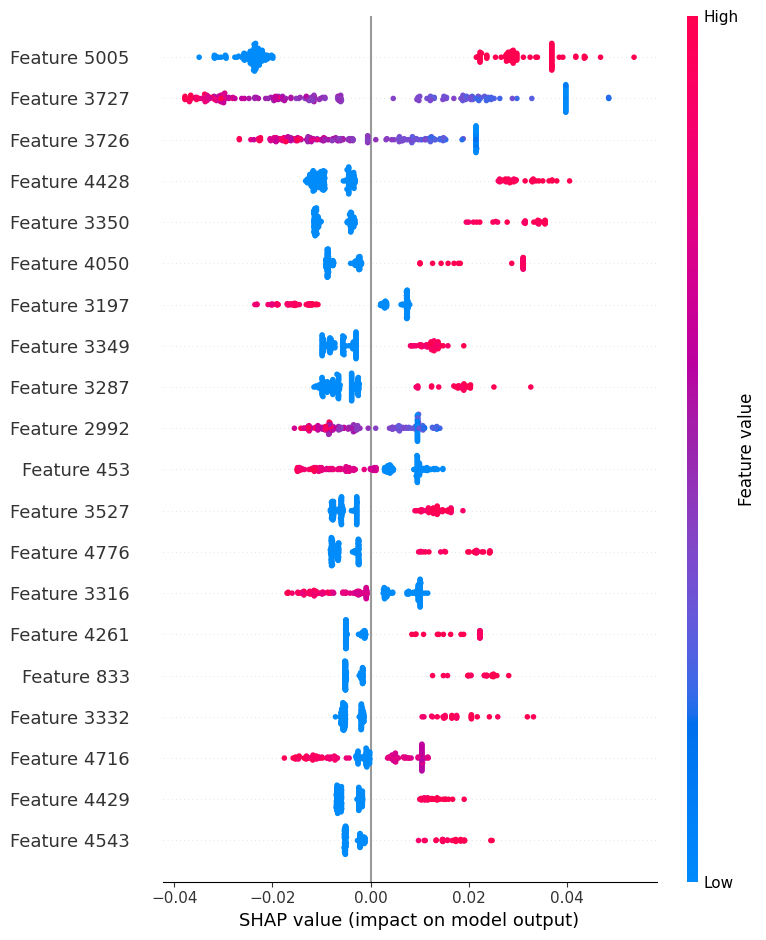

In [34]:
shap.summary_plot(shap_values[:, :, 1], sample)

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(df['label'])

In [40]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=5000, char_level=True)
# char_level=True is IMPORTANT for URLs

tokenizer.fit_on_texts(df['url'])

X_seq = tokenizer.texts_to_sequences(df['url'])

X_pad = pad_sequences(X_seq, maxlen=100)

print("Padded shape:", X_pad.shape)

Padded shape: (2000, 100)


In [41]:
from sklearn.model_selection import train_test_split

X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
    X_pad, y_encoded, test_size=0.2, random_state=42
)

In [42]:
model_lstm = Sequential()

model_lstm.add(Embedding(input_dim=5000, output_dim=64, input_length=100))
model_lstm.add(LSTM(64))
model_lstm.add(Dropout(0.5))
model_lstm.add(Dense(1, activation='sigmoid'))

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [43]:
history = model_lstm.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_lstm, y_test_lstm)
)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 0.7982 - loss: 0.5766 - val_accuracy: 1.0000 - val_loss: 0.0413
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.9990 - loss: 0.0221 - val_accuracy: 1.0000 - val_loss: 0.0078
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 1.0000 - loss: 0.0201 - val_accuracy: 1.0000 - val_loss: 0.0053
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 1.0000 - loss: 0.0065 - val_accuracy: 1.0000 - val_loss: 0.0029
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 1.0000 - loss: 0.0034 - val_accuracy: 1.0000 - val_loss: 0.0018


In [44]:
loss, accuracy = model_lstm.evaluate(X_test_lstm, y_test_lstm)
print("LSTM Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 0.0018
LSTM Accuracy: 1.0


In [46]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf.fit(X_train_hybrid, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [47]:
rf_accuracy = rf.score(X_test_hybrid, y_test)

print("Random Forest Accuracy:", rf_accuracy)
print("LSTM Accuracy:", accuracy)

Random Forest Accuracy: 1.0
LSTM Accuracy: 1.0


In [48]:
def predict_text(text):

    # RF Prediction
    text_tfidf = tfidf.transform([text])
    text_sentiment = np.array([[0]])  # If you used sentiment, modify here
    hybrid_input = hstack([text_tfidf, text_sentiment])
    rf_pred = rf.predict(hybrid_input)

    # LSTM Prediction
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=100)
    lstm_pred = model_lstm.predict(padded)

    print("Random Forest Prediction:", le.inverse_transform(rf_pred)[0])
    print("LSTM Prediction:", "Positive" if lstm_pred > 0.5 else "Negative")

In [50]:
def predict_url(url):

    print("Testing URL:", url)
    print("-" * 40)

    # ---------- Random Forest Prediction ----------
    features = extract_features(url)
    features = np.array(features).reshape(1, -1)

    rf_pred = rf.predict(features)[0]

    print("Random Forest Prediction:",
          "⚠️ Phishing" if rf_pred == 1 else "✅ Safe")

    # ---------- LSTM Prediction ----------
    seq = tokenizer.texts_to_sequences([url])
    padded = pad_sequences(seq, maxlen=100)

    lstm_prob = model_lstm.predict(padded)[0][0]
    lstm_pred = 1 if lstm_prob > 0.5 else 0

    print("LSTM Prediction:",
          "⚠️ Phishing" if lstm_pred == 1 else "✅ Safe")

    print("LSTM Confidence:", round(float(lstm_prob), 4))

In [52]:
import re
import numpy as np
from urllib.parse import urlparse

def extract_features(url):

    features = []

    # 1️⃣ Length of URL
    features.append(len(url))

    # 2️⃣ Number of dots
    features.append(url.count("."))

    # 3️⃣ Has @ symbol
    features.append(1 if "@" in url else 0)

    # 4️⃣ Has IP address
    ip_pattern = r"(\d{1,3}\.){3}\d{1,3}"
    features.append(1 if re.search(ip_pattern, url) else 0)

    # 5️⃣ Uses HTTPS
    features.append(1 if url.startswith("https") else 0)

    # 6️⃣ Number of hyphens
    features.append(url.count("-"))

    # 7️⃣ Number of slashes
    features.append(url.count("/"))

    # 8️⃣ Suspicious keywords
    suspicious_words = ["login", "verify", "secure", "update",
                        "account", "bank", "paypal"]

    features.append(
        1 if any(word in url.lower() for word in suspicious_words) else 0
    )

    # 9️⃣ Length of domain
    parsed = urlparse(url)
    domain = parsed.netloc
    features.append(len(domain))

    return features

In [53]:
from sklearn.ensemble import RandomForestClassifier

# Create feature matrix
X_features = np.array(df['url'].apply(extract_features).tolist())
y = df['label'].values

from sklearn.model_selection import train_test_split

X_train_hybrid, X_test_hybrid, y_train, y_test = train_test_split(
    X_features, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_hybrid, y_train)

print("Random Forest retrained successfully!")

Random Forest retrained successfully!


In [54]:
predict_url("http://secure-login-paypal.ru")

Testing URL: http://secure-login-paypal.ru
----------------------------------------
Random Forest Prediction: ⚠️ Phishing
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step
LSTM Prediction: ⚠️ Phishing
LSTM Confidence: 0.9993


In [55]:
predict_url("https://www.google.com")

Testing URL: https://www.google.com
----------------------------------------
Random Forest Prediction: ✅ Safe
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
LSTM Prediction: ✅ Safe
LSTM Confidence: 0.0037


In [57]:
import joblib

# Save the trained Random Forest model
joblib.dump(rf, "phishing_rf_model.pkl")

print("Model saved successfully as phishing_rf_model.pkl")

Model saved successfully as phishing_rf_model.pkl


In [58]:
print(type(rf))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
